# Dataset MLP vs CNN

Comparação entre duas arquiteturas de redes neurais.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import string
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


# 1. Dataset

Optei por utilizar o 'emnist/letters'. Além disso, separei em treino, validação e teste.

In [10]:
def load_emnist_letters():

    (train_ds, val_ds, test_ds), info = tfds.load(
        'emnist/letters',
        split=['train[:90%]', 'train[90%:]', 'test'],
        as_supervised=True,
        with_info=True
    )
    class_names = info.features['label'].names
    num_classes = len(class_names)
    return train_ds, val_ds, test_ds, info, class_names, num_classes
train_ds, val_ds, test_ds, info, class_names, num_classes = load_emnist_letters()


# 2. Pré Processamento

As imagens vem invertidas horizontalmente e rotacionadas, então vamos corrigir isso primeiro. Ademais, vou converter as imagens para float32 e as normalizar para o intervalo [0,1]. Note que as imagens são em escala de cinza. Além disso, subtrai 1 das labels para que fiquem de 0 a 25, se alinhando com os nomes das classes. 

In [11]:

IMG_SIZE = 28
NUM_CHANNELS = 1


def fix_emnist_orientation(image):
    image = tf.image.rot90(image, k=3)
    image = tf.image.flip_left_right(image)
    return image

def preprocess(image, label):
    image = fix_emnist_orientation(image)
    image = tf.cast(image, tf.float32) / 255.0
    label = label - 1
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

Classes disponíveis: 37


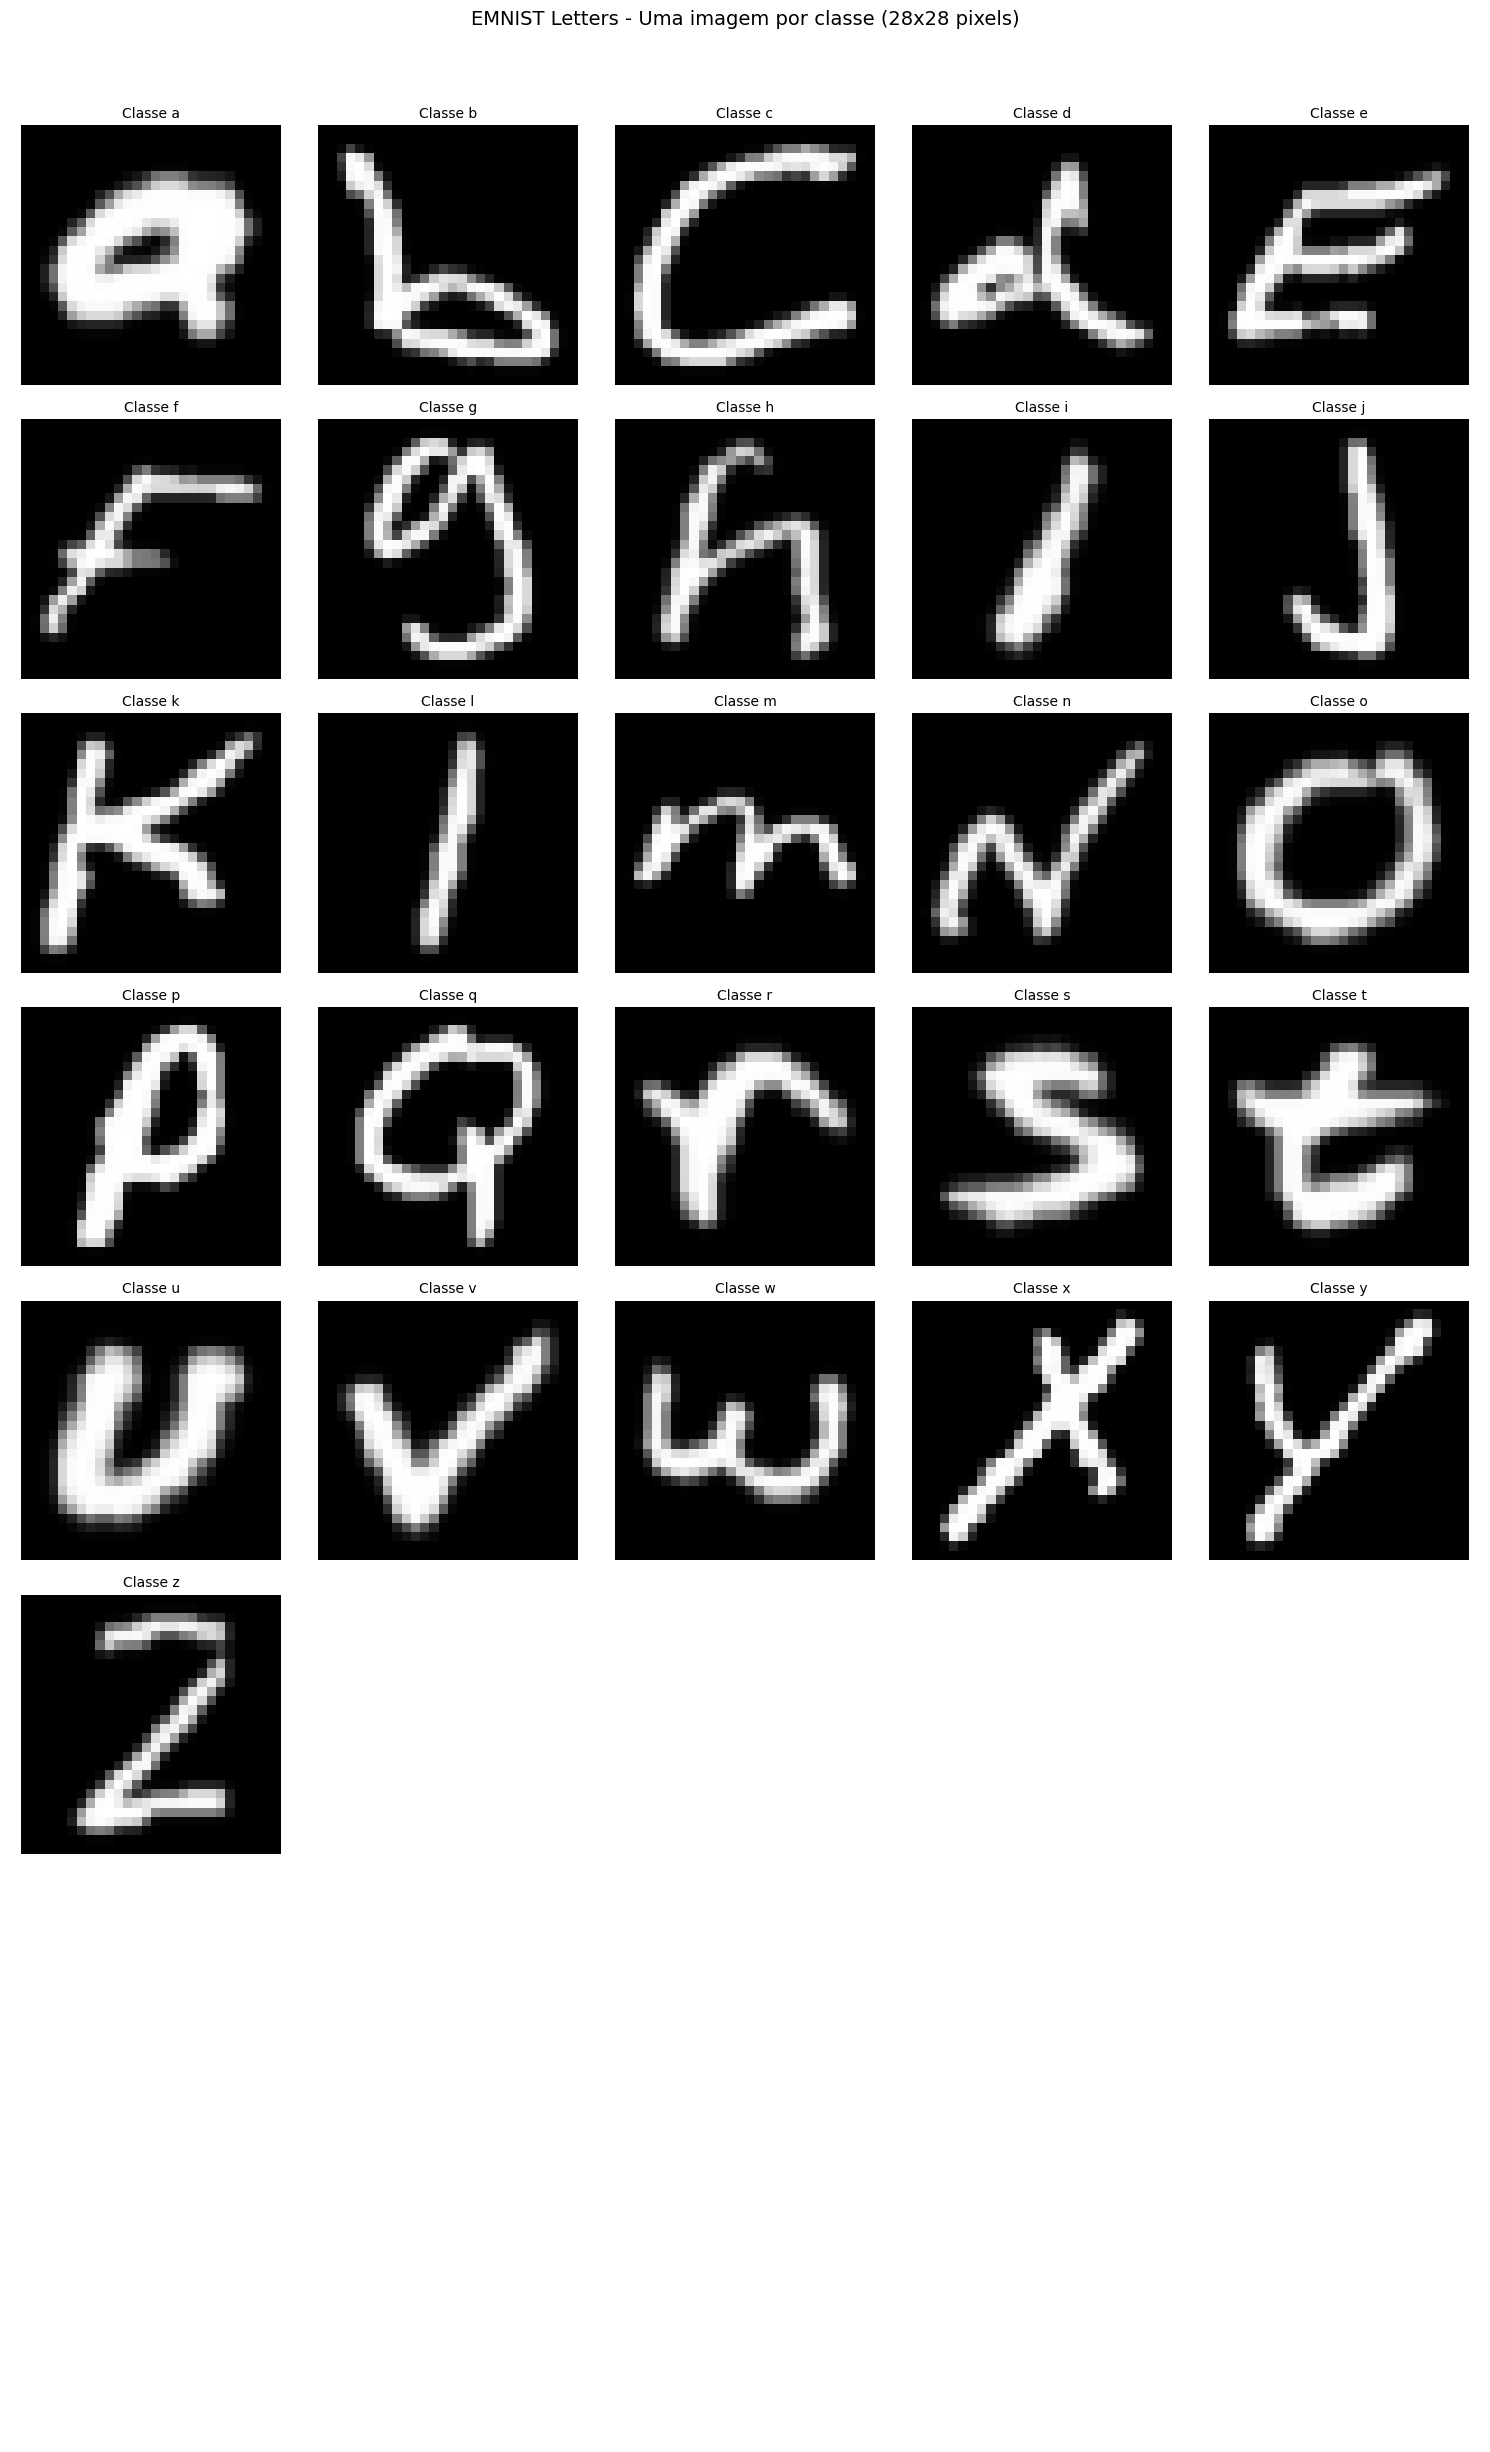


INFORMAÇÕES DO DATASET
Total de imagens de treino: 88,800
Total de imagens de teste: 14,800
Resolução das imagens: 28 x 28 pixels
Número de classes: 37


In [12]:

# ============================================================================
# CLASSES DO EMNIST/LETTERS
# ============================================================================
# Vamos numerar as classes de 0 a 25 apenas para exibição.
# (Se preferir, depois podemos trocar por a, b, c, ..., z.)

num_classes = info.features['label'].num_classes
class_names = list(string.ascii_lowercase)

print(f"Classes disponíveis: {num_classes}")

# Parâmetros para o layout da visualização
n_cols = 5
n_rows = math.ceil(num_classes / n_cols)

# ============================================================================
# Vamos agora exibir uma imagem para cada classe do dataset.
# ============================================================================

samples_by_class = {}

for image, label in train_ds:
    label_id = label.numpy()

    if label_id not in samples_by_class:
        samples_by_class[label_id] = image.numpy()

    if len(samples_by_class) == num_classes:
        break


fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.ravel()

for i, (class_id, image) in enumerate(sorted(samples_by_class.items())):
    ax = axes[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Classe {class_names[class_id]}', fontsize=10)
    ax.axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('EMNIST Letters - Uma imagem por classe (28x28 pixels)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# INFORMAÇÕES ADICIONAIS SOBRE O DATASET
# ============================================================================
print("\n" + "="*50)
print("INFORMAÇÕES DO DATASET")
print("="*50)
print(f"Total de imagens de treino: {info.splits['train'].num_examples:,}")
print(f"Total de imagens de teste: {info.splits['test'].num_examples:,}")
print(f"Resolução das imagens: 28 x 28 pixels")
print(f"Número de classes: {num_classes}")

## 2.2 Conversão dos dados para numpy e função de pré-processamento

Para comparar os modelos de CNN e MLP, vamos converter ambos para numpy. Além disso, vamos definir uma função de pré processamento para que possamos reutilizar tudo. 

In [13]:

def dataset_to_numpy(dataset, max_samples=None):
    """
    Converte um dataset do TensorFlow para numpy arrays.
    Args:
        dataset: tf.data.Dataset
        max_samples: número máximo de amostras (opcional)
    """
    images = []
    labels = []
    
    for i, (image, label) in enumerate(dataset):
        if max_samples and i >= max_samples:
            break
        images.append(image.numpy())
        labels.append(label.numpy())
    
    # Converter para arrays numpy
    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int64)
    
    return X, y

def initialize_and_preprocess():
    train_ds, val_ds, test_ds, info, class_names, num_classes = load_emnist_letters()

    # Pré-processamento
    train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # Converter para NumPy
    X_train, y_train = dataset_to_numpy(train_ds)
    X_val, y_val = dataset_to_numpy(val_ds)
    X_test, y_test = dataset_to_numpy(test_ds)

    return X_train, y_train, X_val, y_val, X_test, y_test, info, class_names, num_classes

## 2.1 Métricas

Aqui, utilizaremos a acurácia.

In [34]:
def evaluate_model(y_true, y_pred):
    print("Accuracy:", accuracy_score(y_true, y_pred))

    labels = np.unique(y_true)

    print("\nClassification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=[class_names[i] for i in labels]
    ))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_norm,
        annot=False,
        cmap='Blues',
        xticklabels=[class_names[i] for i in labels],
        yticklabels=[class_names[i] for i in labels]
    )

    plt.title("Matriz de Confusão Normalizada")
    plt.xlabel("Predição")
    plt.ylabel("Verdadeiro")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 3. MLP

Agora, vamos inicializar o MLP baseado no 2o notebook.

In [22]:
# Recarregando os dados pré-processados.

X_train, y_train, X_val, y_val, X_test, y_test, info, class_names, num_classes = initialize_and_preprocess()

# Para MLP, vamos achatar as imagens.

def prepare_for_mlp(X):
    return X.reshape((X.shape[0], -1))


X_train_flat = prepare_for_mlp(X_train)
X_val_flat = prepare_for_mlp(X_val)
X_test_flat = prepare_for_mlp(X_test)

# Com isso, os dados ficam

print(f"MLP - X_train_flat: {X_train_flat.shape}")
print(f"MLP - X_val_flat: {X_val_flat.shape}")
print(f"MLP - X_test_flat: {X_test_flat.shape}")

MLP - X_train_flat: (79920, 784)
MLP - X_val_flat: (8880, 784)
MLP - X_test_flat: (14800, 784)


## 3.1 Modelo MLP

 O EMNIST Letters tem:
- Imagens 28x28x1
- 784 features após flatten
- 26 classes


In [23]:
mlp = models.Sequential([
    layers.Input(shape=(X_train_flat.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

print("\nArquitetura do modelo MLP:")
mlp.summary()


Arquitetura do modelo MLP:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,629 (932.14 KB)

 Trainable params: 238,629 (932.14 KB)

 Non-trainable params: 0 (0.00 B)

## 3.2 Teste do MLP

A matriz de confusão foi apresentada sem anotações numéricas devido ao grande número de classes (26), utilizando intensidades de cor para facilitar a interpretação visual dos padrões de erro. Além disso, a normalizei.

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

RESULTADOS DA MLP NO EMNIST LETTERS
Accuracy: 0.8952702702702703

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       800
           1       0.94      0.94      0.94       800
           2       0.97      0.92      0.94       800
           3       0.92      0.91      0.91       800
           4       0.92      0.95      0.93       800
           5       0.97      0.91      0.94       800
           6       0.87      0.75      0.81       800
           7       0.91      0.92      0.92       800
           8       0.77      0.70      0.73       800
           9       0.94      0.92      0.93       800
          10       0.96      0.92      0.94       800
          11       0.73      0.80      0.76       800
          12       0.97      0.96      0.97       800
          13       0.94      0.90      0.92       800
          14       0.90      0.97      0.94       800
   

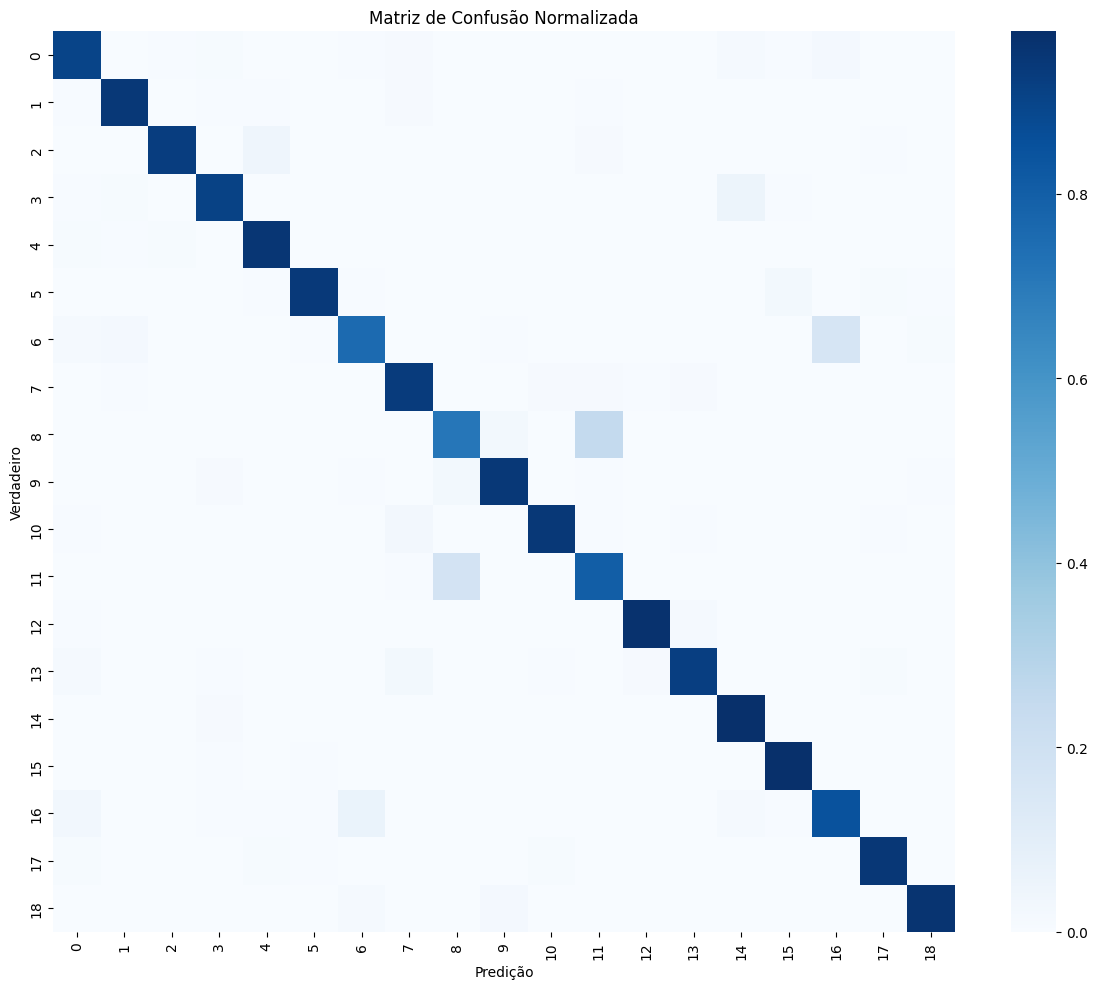


Acurácia final da MLP: 0.8953 (89.53%)


In [35]:
# Avaliação no conjunto de teste

y_pred_probs = mlp.predict(X_test_flat, batch_size=128)
y_pred_mlp = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("RESULTADOS DA MLP NO EMNIST LETTERS")
print("="*50)

evaluate_model(y_test, y_pred_mlp)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"\nAcurácia final da MLP: {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)")

# CNN 

Agora, vamos inicializar a CNN baseada no 3o notebook. 

In [41]:
X_train, y_train, X_val, y_val, X_test, y_test, info, class_names, num_classes = initialize_and_preprocess()


# Nesse caso, não precisamos achatar as imagens.

## 4.1 O modelo CNN
Novamente, temos:
- Imagens 28x28x1
- 26 classes

In [42]:
cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

print("\nArquitetura da CNN para EMNIST Letters:")
cnn.summary()


Arquitetura da CNN para EMNIST Letters:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,517 (892.64 KB)

 Trainable params: 228,517 (892.64 KB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Treinamento do modelo

In [43]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # temos aqui labels inteiras.
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


history_cnn = cnn.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7347 - loss: 0.8677 - val_accuracy: 0.8841 - val_loss: 0.3603
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8670 - loss: 0.4092 - val_accuracy: 0.9063 - val_loss: 0.2877
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.8906 - loss: 0.3354 - val_accuracy: 0.9176 - val_loss: 0.2516
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9038 - loss: 0.2938 - val_accuracy: 0.9199 - val_loss: 0.2526
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9130 - loss: 0.2634 - val_accuracy: 0.9284 - val_loss: 0.2336
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9183 - loss: 0.2419 - val_accuracy: 0.9330 - val_loss: 0.2195
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9233 - loss: 0.2273 - val_accuracy: 0.9300 - val_loss: 0.2151
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9289 - loss: 0.2071 - 

## 4.3 Avaliação do modelo

## 5. Comparação MLP vs CNN

Nesta seção, comparo os dois modelos treinados no mesmo dataset e com o mesmo pré-processamento.

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

RESULTADOS DA CNN NO EMNIST LETTERS
Accuracy: 0.9243918918918919

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       800
           1       0.98      0.95      0.97       800
           2       0.97      0.97      0.97       800
           3       0.97      0.93      0.95       800
           4       0.96      0.97      0.97       800
           5       0.98      0.96      0.97       800
           6       0.90      0.80      0.84       800
           7       0.94      0.95      0.95       800
           8       0.74      0.77      0.75       800
           9       0.98      0.94      0.96       800
          10       0.98      0.95      0.97       800
          11       0.76      0.75      0.76       800
          12       0.99      0.98      0.99       800
          13       0.96      0.95      0.95       800
          14       0.95      0.98      0.96       800
   

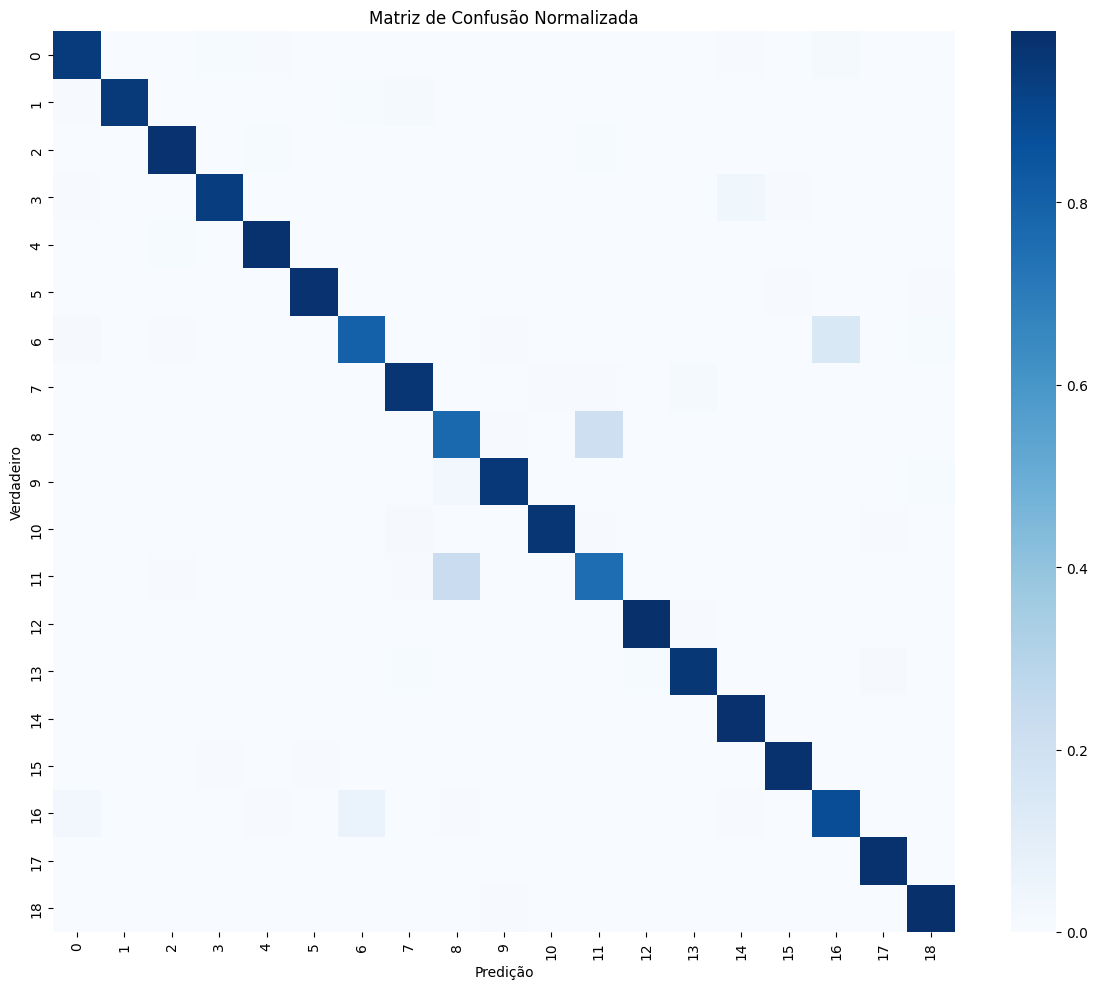

In [ ]:
y_pred_probs = cnn.predict(X_test, batch_size=128)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("RESULTADOS DA CNN NO EMNIST LETTERS")
print("="*50)

evaluate_model(y_test, y_pred_cnn)



## 5. Comparação MLP vs CNN

Nesta seção, comparo os dois modelos treinados.

Comparação final de desempenho
Modelo  Acurácia
   MLP  0.895270
   CNN  0.924392

Diferença entre CNN e MLP: 2.91 pontos percentuais
CNN apresentou melhor desempenho.


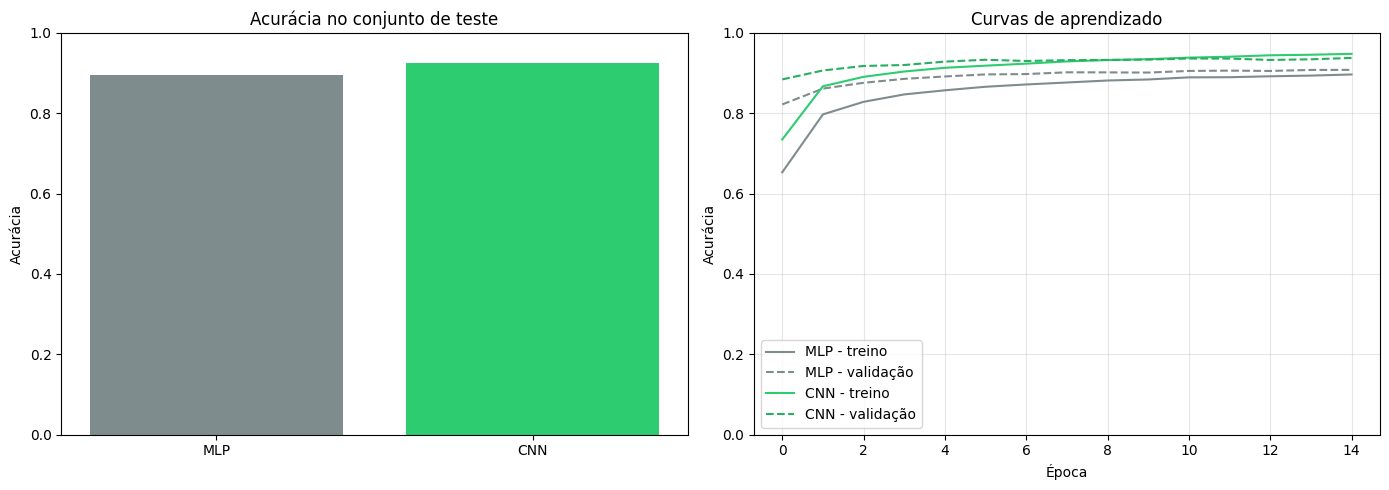

In [45]:
if 'y_pred_cnn' not in globals() or 'history_cnn' not in globals():
    print('Execute as células da CNN antes desta comparação para gerar y_pred_cnn e history_cnn.')
else:
    mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
    cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
    diff_points = (cnn_accuracy - mlp_accuracy) * 100

    comparison = pd.DataFrame({
        'Modelo': ['MLP', 'CNN'],
        'Acurácia': [mlp_accuracy, cnn_accuracy]
    })

    print('Comparação final de desempenho')
    print(comparison.to_string(index=False))
    print(f'\nDiferença entre CNN e MLP: {diff_points:.2f} pontos percentuais')
    print('CNN apresentou melhor desempenho.' if cnn_accuracy > mlp_accuracy else 'MLP apresentou melhor desempenho.')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(['MLP', 'CNN'], [mlp_accuracy, cnn_accuracy], color=['#7f8c8d', '#2ecc71'])
    axes[0].set_title('Acurácia no conjunto de teste')
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('Acurácia')

    axes[1].plot(history_mlp.history['accuracy'], label='MLP - treino', color='#7f8c8d')
    axes[1].plot(history_mlp.history['val_accuracy'], label='MLP - validação', color='#7f8c8d', linestyle='--')
    axes[1].plot(history_cnn.history['accuracy'], label='CNN - treino', color='#2ecc71')
    axes[1].plot(history_cnn.history['val_accuracy'], label='CNN - validação', color='#27ae60', linestyle='--')
    axes[1].set_title('Curvas de aprendizado')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

A diferença de desempenho entre MLP e CNN foi relativamente pequena, o que pode ser explicado pela simplicidade do dataset EMNIST, composto por imagens pequenas (28x28) e com baixo nível de ruído. Ainda assim, a CNN apresentou melhor desempenho, evidenciando sua capacidade superior de capturar padrões espaciais, mesmo em problemas mais simples.